# Box-cox Transform
- The exponent here is a variable called lambda (λ) that varies over the range of -5 to 5, and in the process of searching , we examine all values of λ.finally, we choose the optimalalue (resulting in the best approximation to a normal distribution) for your variable.

` There is a  restriction to box cox i.e the value of the data should not be in negative and should be greater then 0`

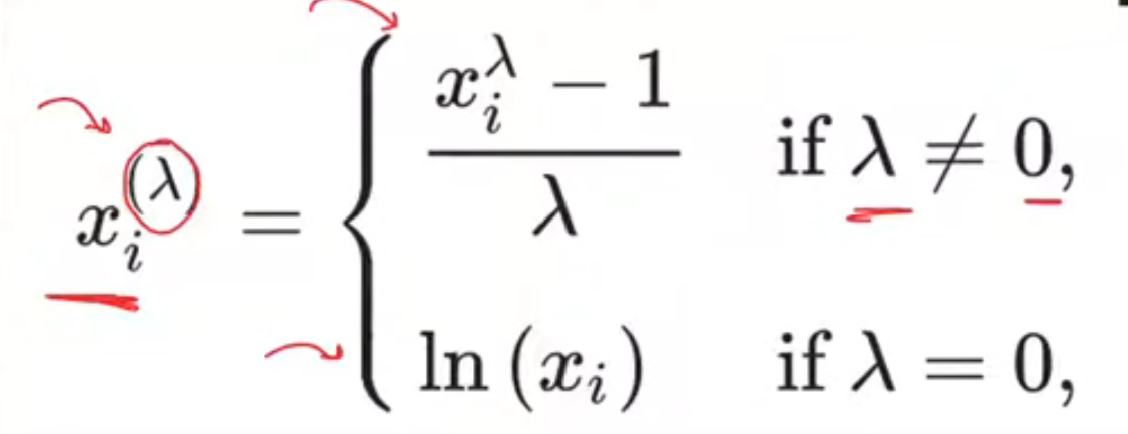
 

# Yeo johonson Transform 
- This transformation is somewhat of an adjustment  to the box-cox transformation, by which we can apply it to negative numbers.

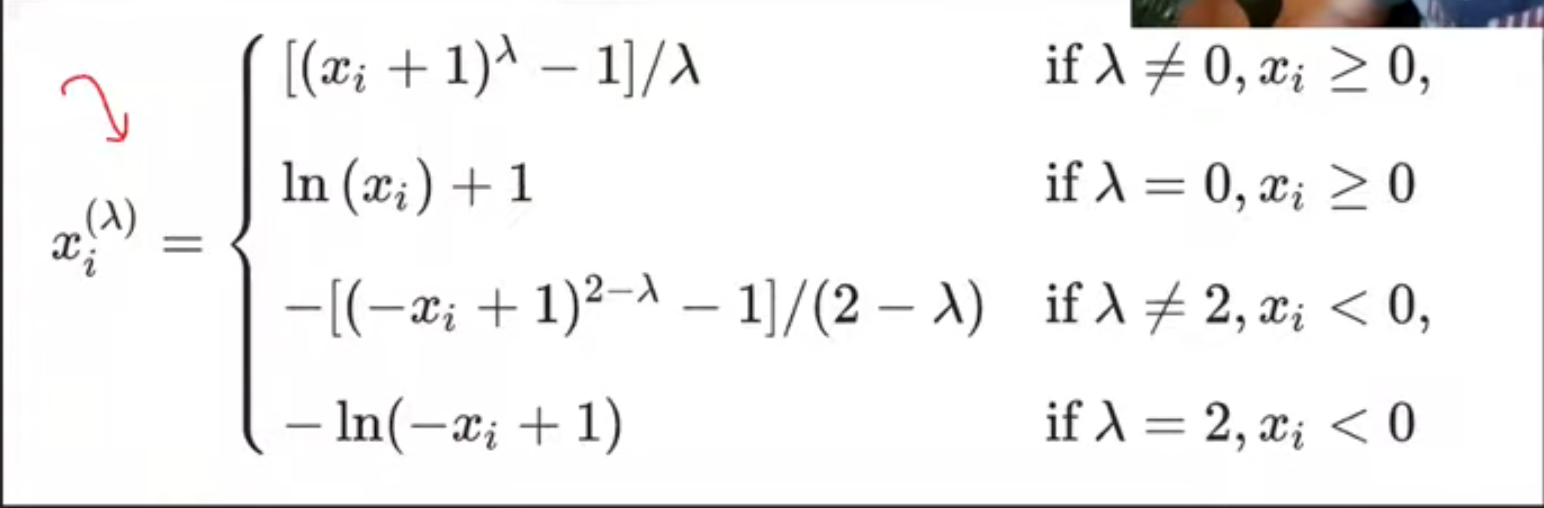

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [4]:
df = pd.read_csv('E:\\WORK\\AI-ML\\data\\concrete_data.csv')

In [5]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [7]:
df.shape

(1030, 9)

In [8]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

- `df` is your full DataFrame.

- `df.drop(columns=['Strength'])` means:

  ```python
  X = df.drop(columns=['Strength'])
  ```

  Remove the column named **`Strength`** from `df`.

- So `X` contains **all columns except `Strength`**.

- `columns=['Strength']` tells pandas:

  ```text
  Drop this column, not a row.
  ```

- Why do we write `columns=`?

  Because `drop()` can remove both rows and columns.

  ```python
  df.drop(index=[0])
  ```

  removes row with index `0`.

  ```python
  df.drop(columns=['Strength'])
  ```

  removes column named `Strength`.

- This line:

  ```python
  y = df.iloc[:, -1]
  ```

  means:

  ```text
  Select all rows, and select the last column.
  ```

- Since `Strength` is the last column, this means:

  ```python
  y = df['Strength']
  ```

- So no, `X` and `y` do **not** become the same.

- They are different because:

  ```python
  X = df.drop(columns=['Strength'])
  ```

  gives the **input features**.

  ```python
  y = df.iloc[:, -1]
  ```

  gives the **target/output column**.

- Example:

  ```text
  df columns:
  Cement | Water | Age | Strength
  ```

- After this:

  ```python
  X = df.drop(columns=['Strength'])
  ```

  `X` becomes:

  ```text
  Cement | Water | Age
  ```

- And:

  ```python
  y = df.iloc[:, -1]
  ```

  `y` becomes:

  ```text
  Strength
  ```

- So in ML terms:

  ```text
  X = input data/features
  y = output/target/label
  ```

- Important point:

  `drop()` here does **not permanently change** `df` unless you use:

  ```python
  inplace=True
  ```

  Example:

  ```python
  df.drop(columns=['Strength'], inplace=True)
  ```

- In your code, original `df` still has the `Strength` column.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
# Applying Regression without any transformation
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.6275531792314848

- **R² score** stands for **coefficient of determination**.

- It is used to evaluate **regression models**.

- It tells us how well the model explains the variation in the actual target values.

- In simple words:

  ```text
  R² score tells how close the predicted values are to the actual values.
  ```

- Formula:

  ```text
  R² = 1 - (SS_res / SS_total)
  ```

- Where:

  ```text
  SS_res   = sum of squared errors between actual and predicted values
  SS_total = sum of squared errors between actual values and their mean
  ```

- Interpretation:

  | R² Score | Meaning |
  |---|---|
  | `1.0` | Perfect prediction |
  | `0.0` | Model performs like predicting the mean |
  | `< 0` | Model is worse than predicting the mean |
  | Closer to `1` | Better model performance |

- Example:

  ```text
  R² = 0.85
  ```

  This means the model explains **85% of the variance** in the target variable.

- In Python:

  ```python
  from sklearn.metrics import r2_score

  r2_score(y_test, y_pred)
  ```

- Important note:

  - A high R² score does **not always mean the model is perfect**.
  - You should also check errors like:
    - **MAE**
    - **MSE**
    - **RMSE**

In [12]:
# Cross checking with cross val score
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.46099404916628683)

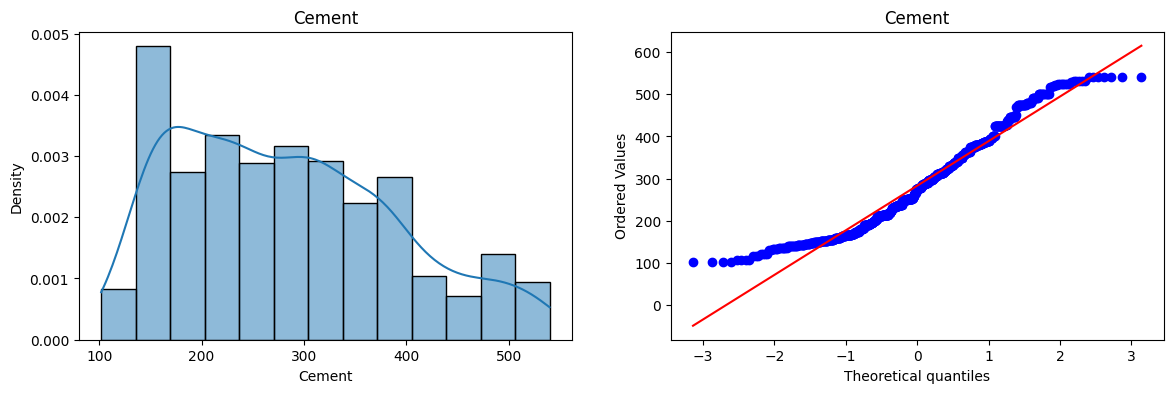

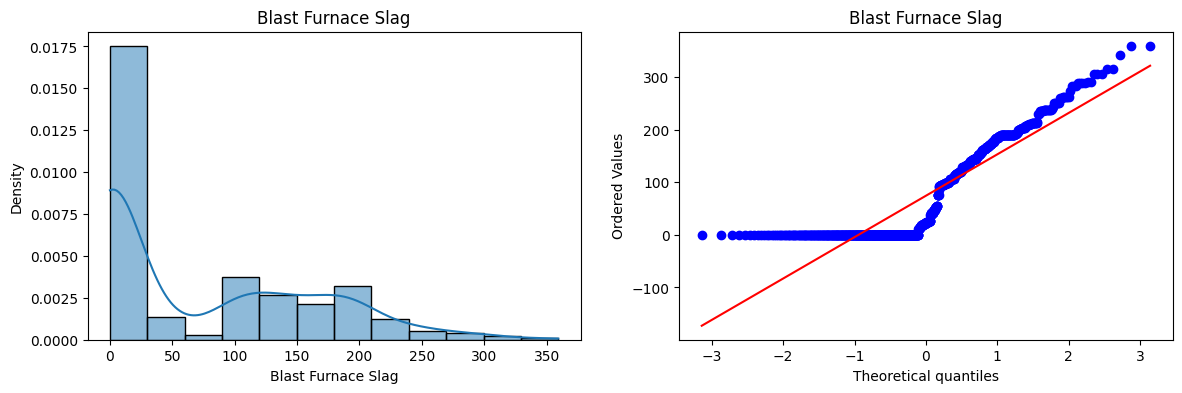

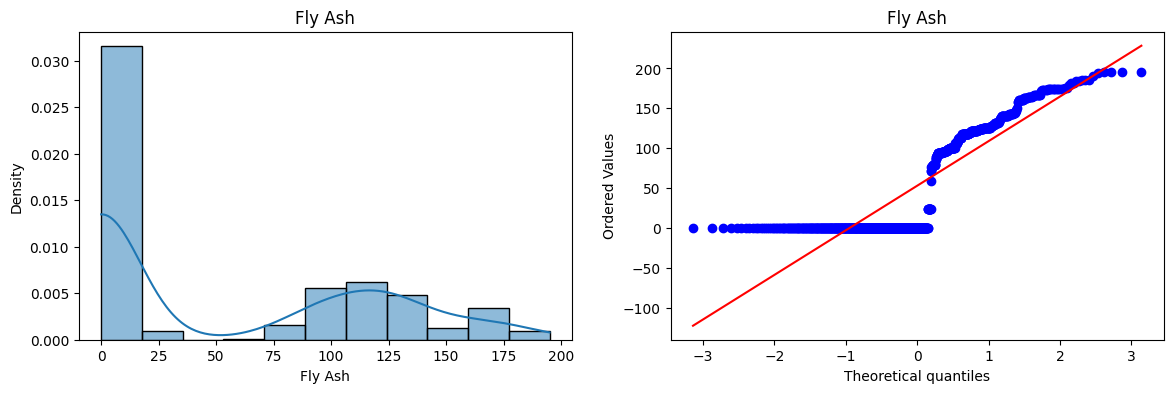

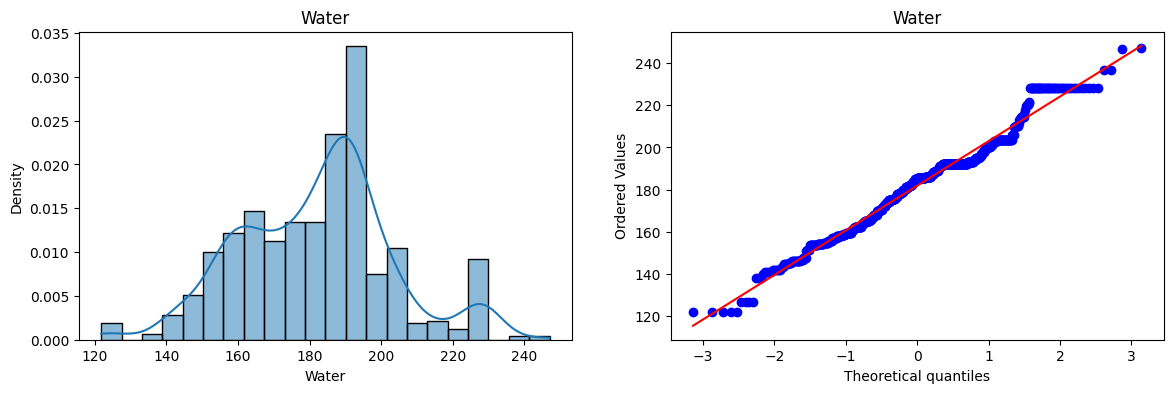

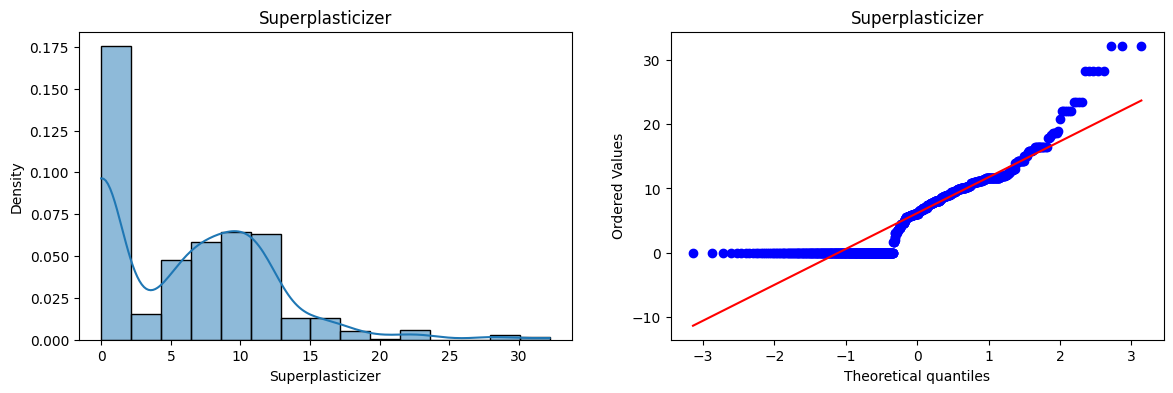

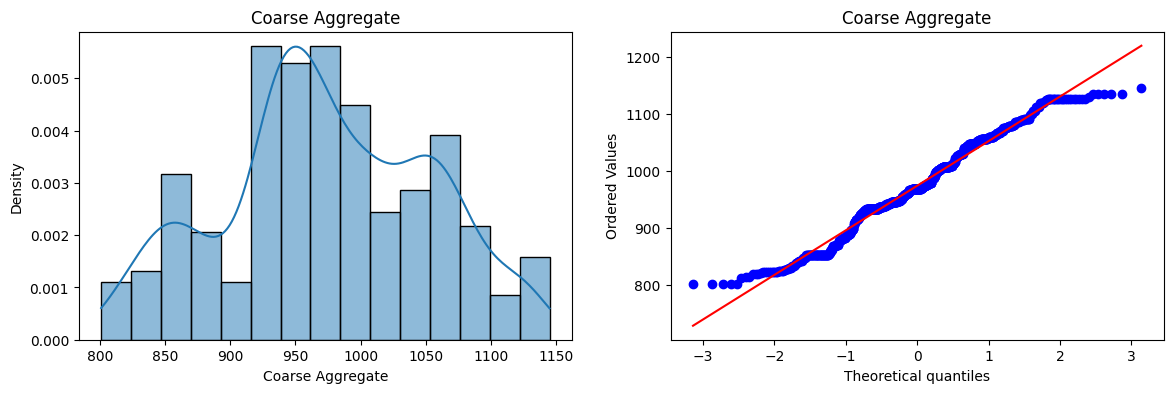

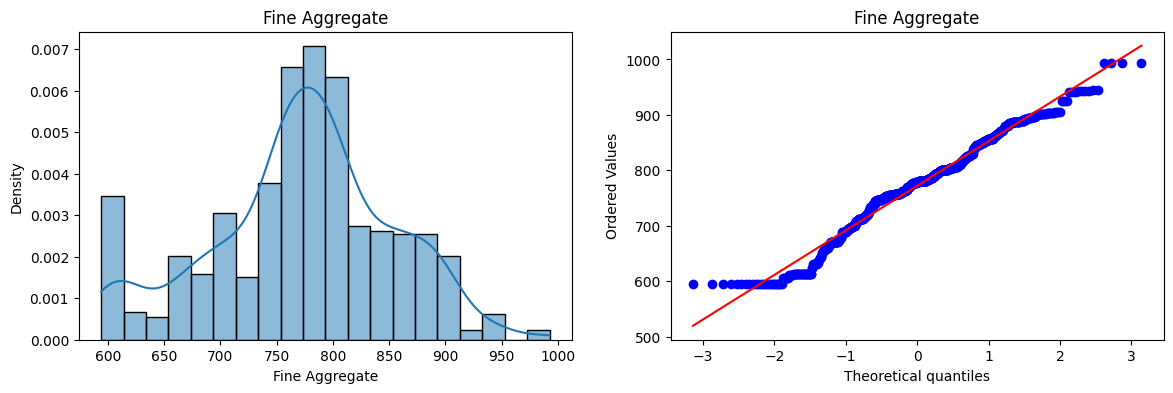

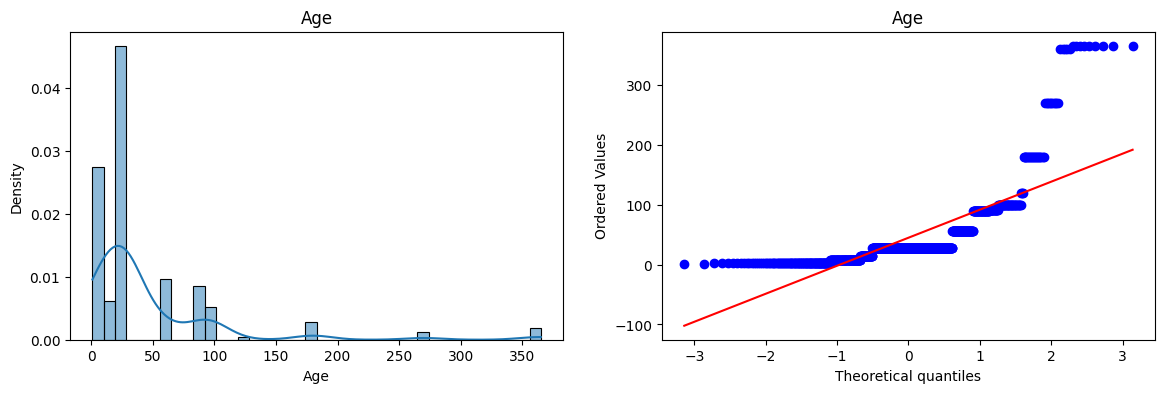

In [17]:
# Plotting the histograms without any transformation

for col in X_train.columns: # .columns will give the list of all the columns in the dataframe
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True,stat='density') # here kde=True is used to plot the kernel
                                                    # density estimation and stat='density' is used to plot the density of the data.
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt) # here dist="norm" is used to check 
                                                        # the normality of the data. If the data
                                                        #  is normally distributed, then the points
                                                        #  will lie on the straight line. and
                                                        #  plot=plt is used to plot the graph.
    plt.title(col)

    plt.show()

In [18]:
# Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [19]:
# Applying linear regression on transformed data

lr = LinearRegression()
lr.fit(X_train_transformed,y_train)

y_pred2 = lr.predict(X_test_transformed)

r2_score(y_test,y_pred2)

0.8047825008078887

In [20]:
# Using cross val score

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))


np.float64(0.6658537941434357)

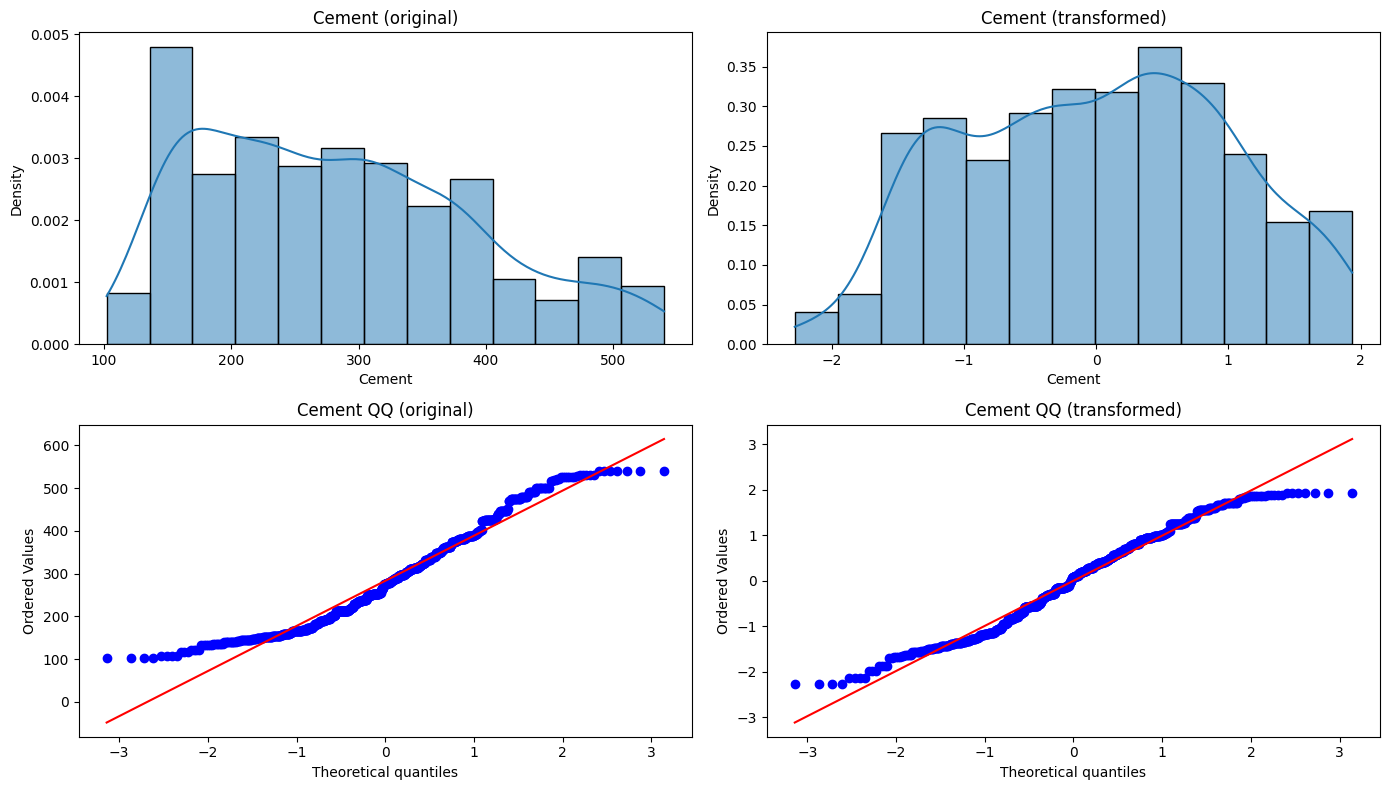

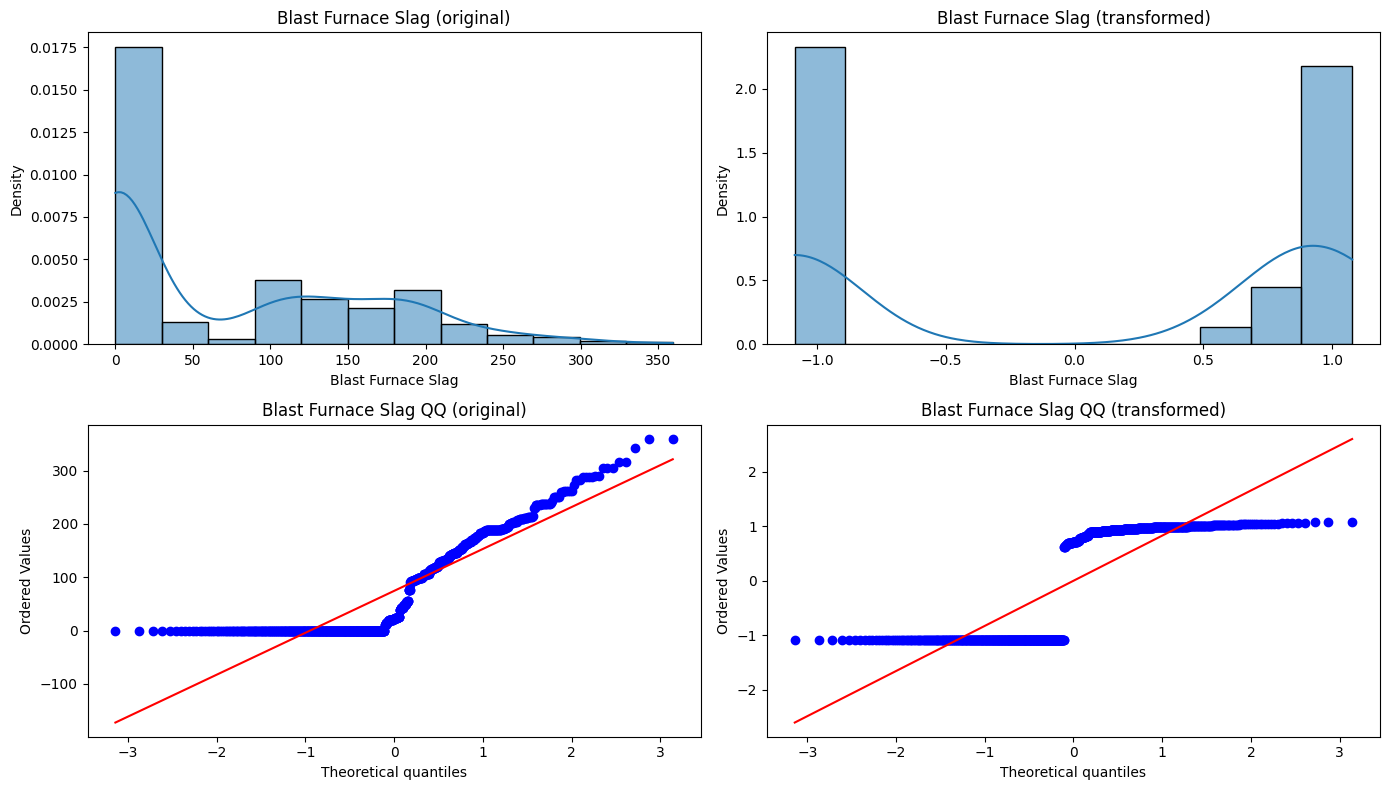

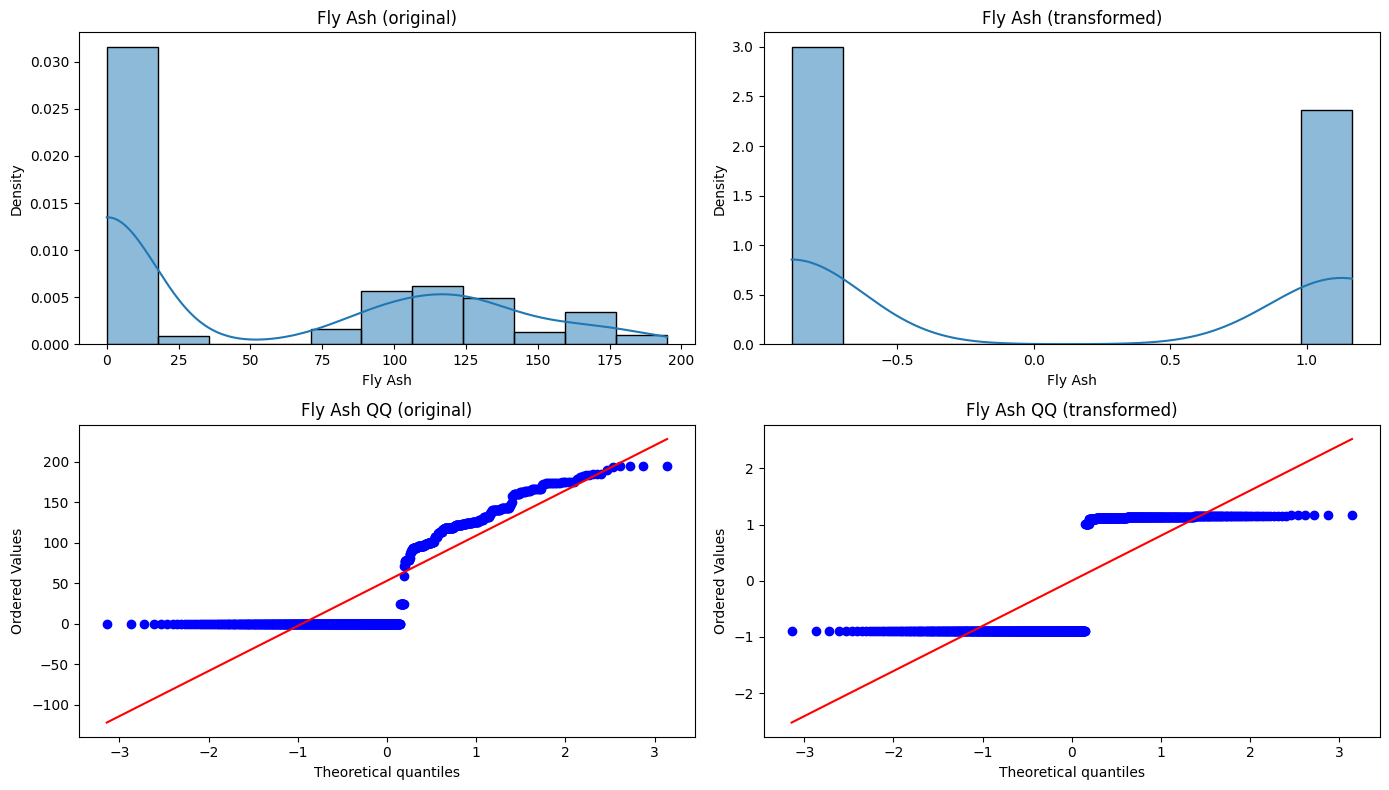

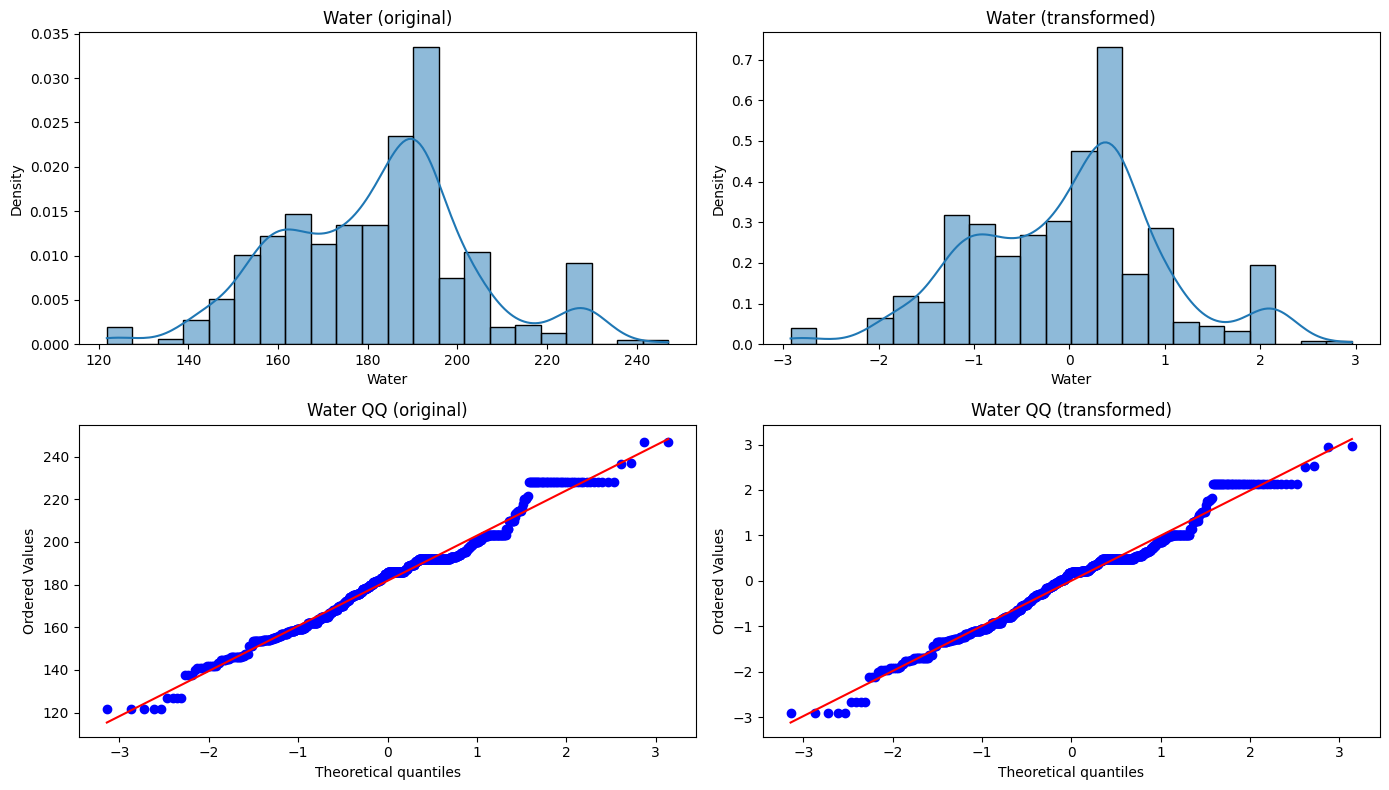

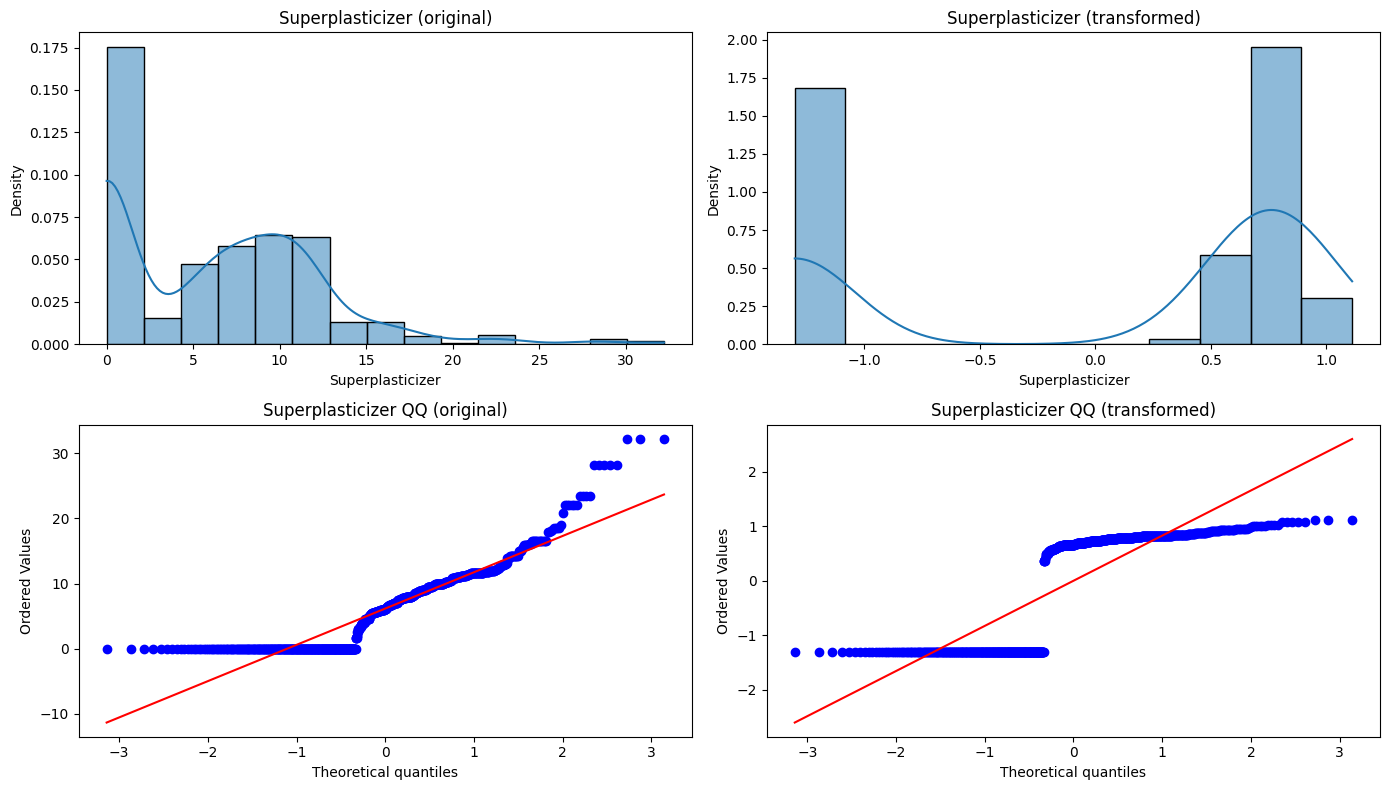

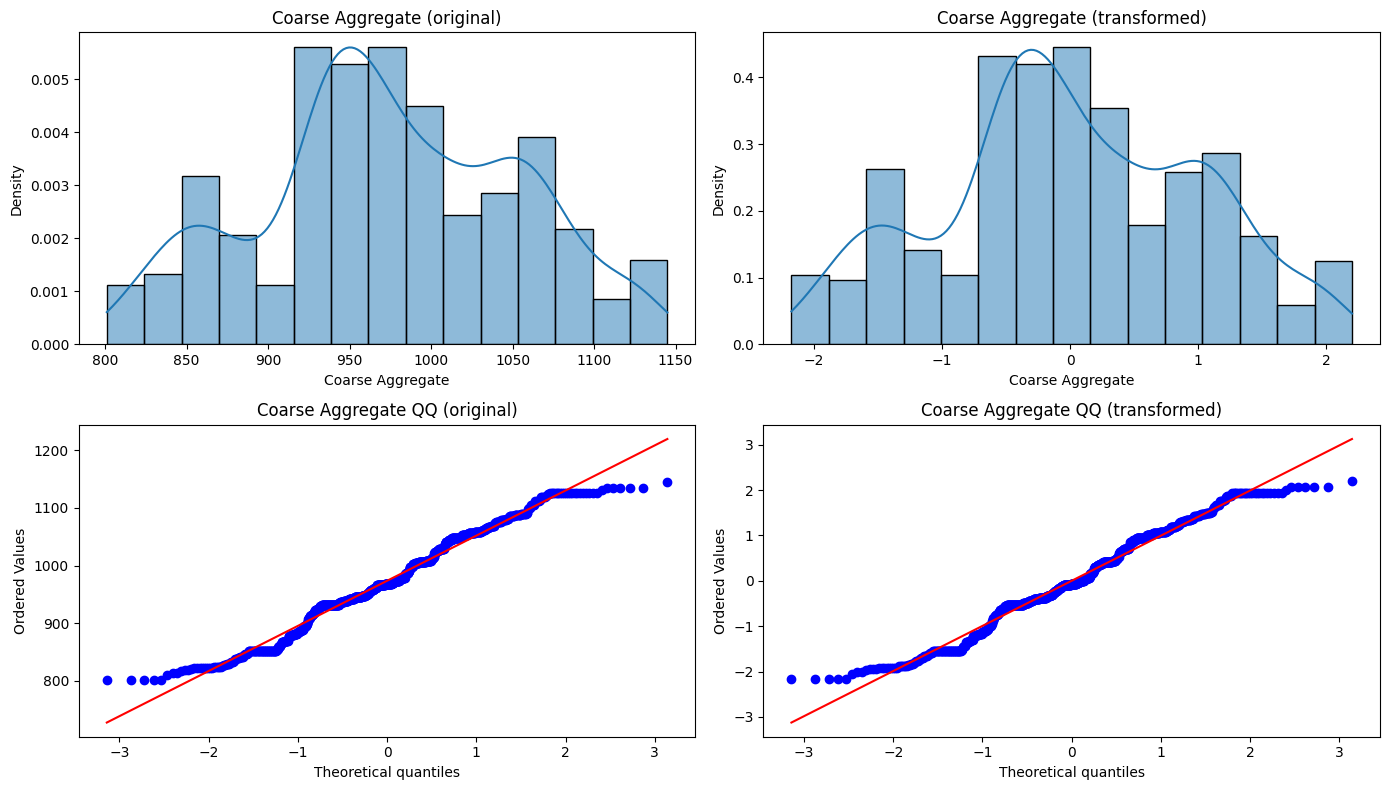

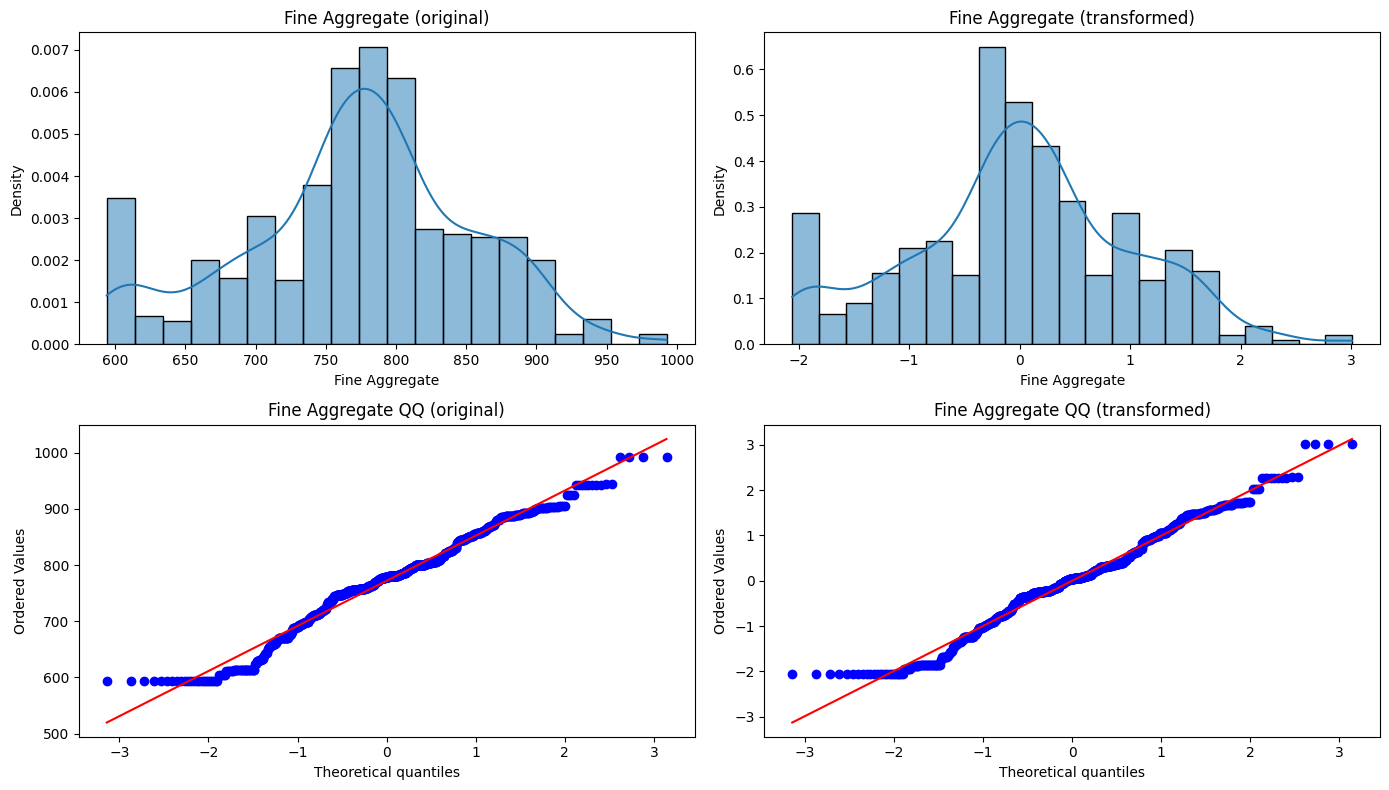

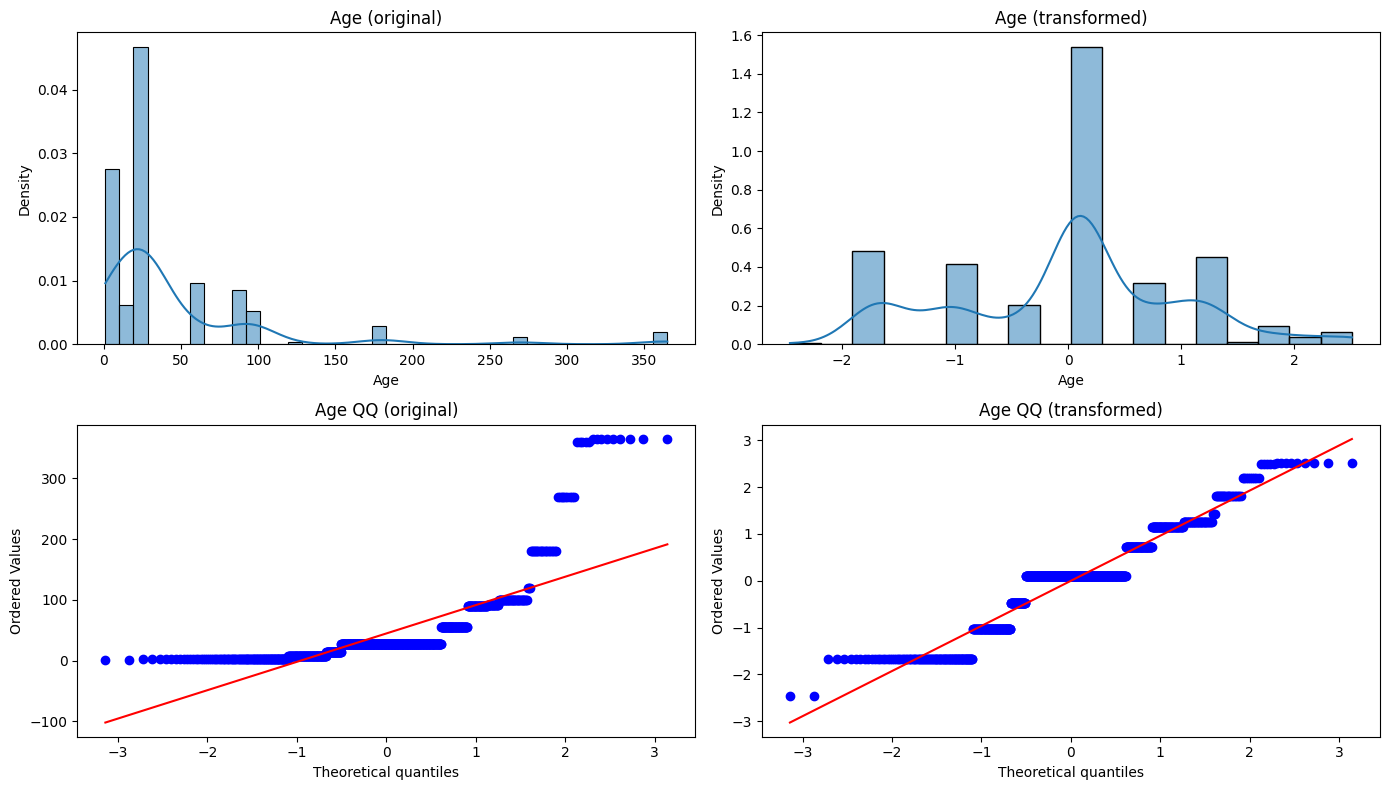

In [27]:
# Before and after comparision for Box-Cox Plot
X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    sns.histplot(X_train[col], kde=True, stat='density', ax=axes[0, 0])
    axes[0, 0].set_title(f"{col} (original)")

    sns.histplot(X_train_transformed[col], kde=True, stat='density', ax=axes[0, 1])
    axes[0, 1].set_title(f"{col} (transformed)")

    plt.sca(axes[1, 0])
    stats.probplot(X_train[col], dist="norm", plot=plt)
    axes[1, 0].set_title(f"{col} QQ (original)")

    plt.sca(axes[1, 1])
    stats.probplot(X_train_transformed[col], dist="norm", plot=plt)
    axes[1, 1].set_title(f"{col} QQ (transformed)")

    plt.tight_layout()
    plt.show()

In [22]:
# Apply Yeo-Johnson transform

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.8161906511066099


,cols,Yeo_Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885



- `fit_transform`: runs `fit()` to learn transformation parameters from the given data, then immediately applies the transformation. Example: for a scaler it computes mean/std from the data and returns the scaled values.
  - In your code: `pt1.fit_transform(X_train)` — learns the Yeo‑Johnson lambdas (and any other params) from the training set and transforms X_train.

- `transform`: applies a previously learned transformation (no re-fitting). It uses the parameters learned earlier.
  - In your code: `pt1.transform(X_test)` — uses the lambdas learned from X_train to transform X_test.

Why they were used differently:
- To avoid data leakage. You must learn (fit) transformation only on the training data, then apply the exact same transformation to validation/test data. This ensures your model never "sees" information from the test set during preprocessing.

Tiny illustrative example:
- `scaler = StandardScaler()`
- `X_train_scaled = scaler.fit_transform(X_train)`  # learns mean/std from train
- `X_test_scaled  = scaler.transform(X_test)`       # uses train mean/std to scale test

That's it — use `fit_transform` on training data, `transform` on any new/unseen data.

In [23]:
# applying cross val score

pt = PowerTransformer()
X_transformed2 = pt.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed2,y,scoring='r2'))

np.float64(0.6834625126992434)

In [24]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=X_train.columns)

In [ ]:
# Before and after comparision for Yeo-Johnson

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True,stat='density')
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_transformed2[col],kde=True,stat='density')
    plt.title(col)

    plt.show()

In [25]:
# Side by side Lambdas
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.169544,0.174348
1,Blast Furnace Slag,0.016633,0.015715
2,Fly Ash,-0.136480,-0.161447
3,Water,0.808438,0.771307
4,Superplasticizer,0.264160,0.253935
5,Coarse Aggregate,1.129395,1.130050
6,Fine Aggregate,1.830764,1.783100
7,Age,0.001771,0.019885
